##**Name:** Massab Naeem
##**Github:** https://github.com/massabnaeem05-create/hybrid-nuclei-analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile, os

ZIP_PATH = '/content/drive/MyDrive/nuclei_dataset.zip'
EXTRACT_DIR = '/content/nuclei_dataset'

if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('/content/')

print(os.listdir(EXTRACT_DIR))

['train', 'metadata.csv', 'dataset_summary.json', 'make_dataset.py', 'README.md', 'val', 'test_corrupted', 'test']


### Install & pin Ollama, pull llava

In [ ]:
!apt-get update && apt-get install -y zstd

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,578 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [108 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,908 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.7 MB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main a

In [ ]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [ ]:
!ollama serve > /tmp/ollama.log 2>&1 &

In [ ]:
!sleep 3
!ollama --version

ollama version is 0.32.14


In [ ]:
!ollama pull llava

### Preprocessing function

In [ ]:
import numpy as np
from PIL import Image
import pandas as pd

TRAIN_DIR = f'{EXTRACT_DIR}/train'
metadata = pd.read_csv(f'{EXTRACT_DIR}/metadata.csv')
print(metadata.head())
print(metadata['density'].value_counts())

def preprocess_image(image_path, target_size=(256, 256)):

    img_rgb = Image.open(image_path).convert('RGB')
    if img_rgb.size != target_size:
        img_rgb = img_rgb.resize(target_size, Image.BILINEAR)

    img_gray = img_rgb.convert('L')
    gray_array = np.array(img_gray, dtype=np.float32) / 255.0

    return {
        'rgb_image': img_rgb,
        'gray_array': gray_array,
        'path': image_path
    }

# quick test on one image
sample_id = metadata[metadata['split'] == 'train'].iloc[0]['image_id']
sample_path = f'{TRAIN_DIR}/images/{sample_id}.png'
sample = preprocess_image(sample_path)
print(sample['rgb_image'].size, sample['gray_array'].shape, sample['gray_array'].dtype)

    image_id  split density  n_objects  mean_intensity  area_fraction  \
0  train_000  train  sparse         10        0.747476       0.019333   
1  train_001  train  normal         29        0.736130       0.086044   
2  train_002  train  normal         17        0.703992       0.040680   
3  train_003  train  normal         36        0.716404       0.101517   
4  train_004  train   dense         85        0.763909       0.202789   

       seed  
0  20260715  
1  20260716  
2  20260717  
3  20260718  
4  20260719  
density
normal       56
sparse       20
dense        18
clustered    18
Name: count, dtype: int64
(256, 256) (256, 256) float32


### EDA: sample grid across density regimes + intensity histogram

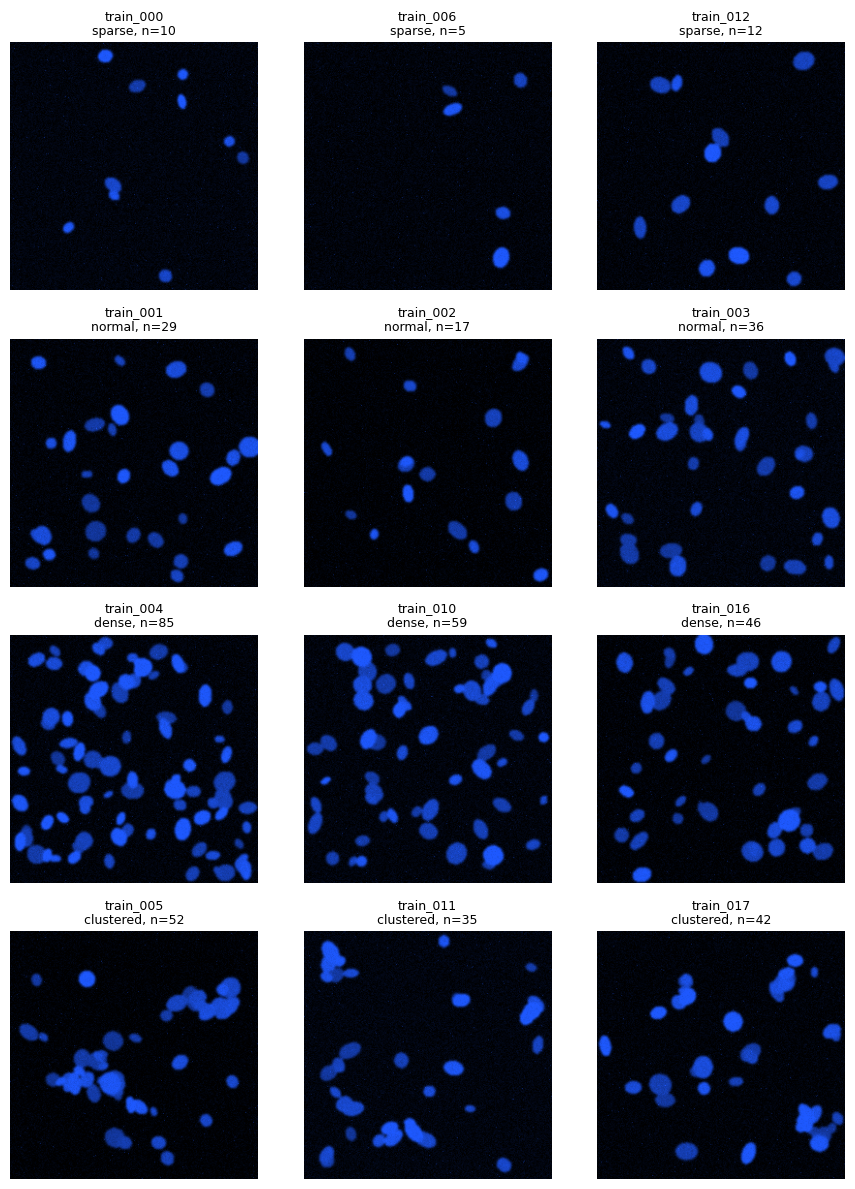

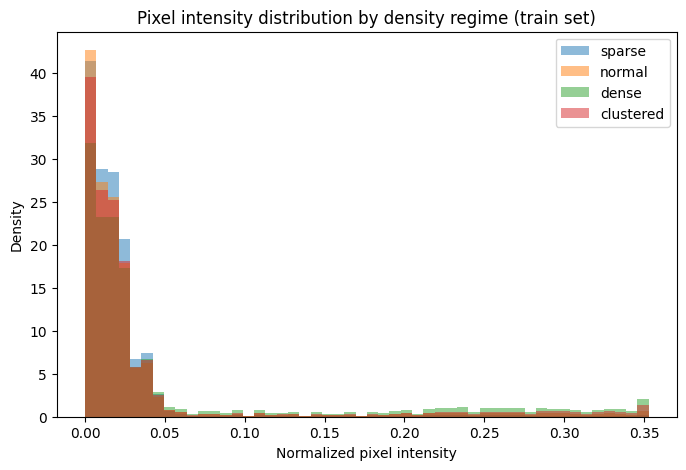

In [ ]:
import matplotlib.pyplot as plt

train_meta = metadata[metadata['split'] == 'train']

# Pick a few images per density regime for the grid
densities = ['sparse', 'normal', 'dense', 'clustered']
samples_per_density = 3
grid_ids = []
for d in densities:
    ids = train_meta[train_meta['density'] == d]['image_id'].head(samples_per_density).tolist()
    grid_ids.extend(ids)

fig, axes = plt.subplots(len(densities), samples_per_density, figsize=(9, 12))
for i, img_id in enumerate(grid_ids):
    row, col = divmod(i, samples_per_density)
    img_path = f'{TRAIN_DIR}/images/{img_id}.png'
    img = Image.open(img_path)
    axes[row, col].imshow(img)
    row_meta = train_meta[train_meta['image_id'] == img_id].iloc[0]
    axes[row, col].set_title(f"{img_id}\n{row_meta['density']}, n={row_meta['n_objects']}", fontsize=9)
    axes[row, col].axis('off')
plt.tight_layout()
plt.savefig('/content/eda_sample_grid.png', dpi=150)
plt.show()

# Intensity histogram: pooled grayscale pixel intensities, split by density regime
plt.figure(figsize=(8, 5))
for d in densities:
    ids = train_meta[train_meta['density'] == d]['image_id'].tolist()
    all_pixels = []
    for img_id in ids:
        gray = np.array(Image.open(f'{TRAIN_DIR}/images/{img_id}.png').convert('L'), dtype=np.float32) / 255.0
        all_pixels.append(gray.ravel())
    all_pixels = np.concatenate(all_pixels)
    plt.hist(all_pixels, bins=50, alpha=0.5, label=d, density=True)

plt.xlabel('Normalized pixel intensity')
plt.ylabel('Density')
plt.title('Pixel intensity distribution by density regime (train set)')
plt.legend()
plt.savefig('/content/eda_intensity_histogram.png', dpi=150)
plt.show()

### Ollama VLM prompts: naive vs engineered, with non-determinism demo

In [ ]:
!pip install -q ollama

In [ ]:
import ollama
import json

# pick one sample image for both prompts
demo_image_path = sample_path

# Naive prompt
naive_prompt = "Describe this image."

naive_response = ollama.chat(
    model='llava',
    messages=[{
        'role': 'user',
        'content': naive_prompt,
        'images': [demo_image_path]
    }]
)
print("=== NAIVE PROMPT OUTPUT ===")
print(naive_response['message']['content'])
print()



=== NAIVE PROMPT OUTPUT ===
 The image displays a dark sky background, which appears to be a night sky. Overlaid on this background are multiple white dots scattered across the image, resembling stars or constellations. The dots are dispersed throughout the image in no particular pattern. The style of the image is a simple, digital representation, possibly used to illustrate a concept or to represent a sky filled with stars. There are no texts or additional graphics in the image. The focus is solely on the dots, which are the only visible elements. 



In [ ]:
# Engineered prompt
engineered_prompt = """You are assisting with descriptive image analysis for a research pipeline, not clinical diagnosis.

Look at this microscopy image and describe what you observe. Respond ONLY with valid JSON in exactly this format:
{
  "modality": "<imaging modality you observe, e.g. fluorescence microscopy>",
  "tissue_type": "<what kind of biological sample this appears to be>",
  "notable_features": "<brief description of visible structures, density, arrangement>",
  "image_quality": "<assessment of contrast, focus, noise>"
}

If you are not confident about any field, write "uncertain" for that field instead of guessing. Do not include any text outside the JSON object."""

print("=== ENGINEERED PROMPT OUTPUT (3 runs, same image, to show non-determinism) ===")
engineered_outputs = []
for i in range(3):
    resp = ollama.chat(
        model='llava',
        messages=[{
            'role': 'user',
            'content': engineered_prompt,
            'images': [demo_image_path]
        }]
    )
    content = resp['message']['content']
    engineered_outputs.append(content)
    print(f"--- Run {i+1} ---")
    print(content)
    print()

# Save all outputs for the report
with open('/content/task1_vlm_outputs.json', 'w') as f:
    json.dump({
        'image_id': sample_id,
        'naive_prompt': naive_prompt,
        'naive_output': naive_response['message']['content'],
        'engineered_prompt': engineered_prompt,
        'engineered_outputs_3runs': engineered_outputs
    }, f, indent=2)


=== ENGINEERED PROMPT OUTPUT (3 runs, same image, to show non-determinism) ===
--- Run 1 ---
 ```json
{
  "modality": "fluorescence microscopy",
  "tissue_type": "not certain",
  "notable_features": "The image features multiple green spots, distributed unevenly throughout the frame. The background is dark, indicating a good contrast with the green fluorescence, which suggests a focus on the spots. The noise level appears low, allowing for clear observation of the spots.",
  "image_quality": "The image has a high contrast and focus, with low noise levels, suggesting a well-prepared sample and a suitable imaging technique."
}
``` 

--- Run 2 ---
 {
  "modality": "fluorescence microscopy",
  "tissue_type": "uncertain",
  "notable_features": "The image appears to show microscopic particles or cells with a bright, round nucleus and a less bright cytoplasm, arranged in a somewhat scattered pattern. There is a dark background, and the focus seems uneven with some structures more in focus than

### Otsu segmentation + morphological cleanup + regionprops

In [ ]:
from skimage import filters, morphology, measure
import numpy as np
import pandas as pd

def extract_classical_features(gray_array, min_object_size=10):

    # Otsu threshold
    thresh_val = filters.threshold_otsu(gray_array)
    binary = gray_array > thresh_val

    # Morphological cleanup: remove small noise, close small gaps
    cleaned = morphology.remove_small_objects(binary, min_size=min_object_size)
    cleaned = morphology.binary_closing(cleaned, morphology.disk(2))
    cleaned = morphology.remove_small_holes(cleaned, area_threshold=min_object_size)

    # Connected components
    labeled = measure.label(cleaned)

    # Regionprops table
    props = measure.regionprops_table(
        labeled, intensity_image=gray_array,
        properties=['label', 'area', 'eccentricity', 'solidity',
                    'mean_intensity', 'perimeter', 'major_axis_length',
                    'minor_axis_length', 'extent']
    )
    props_df = pd.DataFrame(props)

    return {
        'threshold': thresh_val,
        'binary_mask': cleaned,
        'labeled_mask': labeled,
        'n_objects': int(labeled.max()),
        'props_df': props_df
    }

result = extract_classical_features(sample['gray_array'])
print(f"Otsu threshold: {result['threshold']:.4f}")
print(f"Detected objects: {result['n_objects']}")
print(result['props_df'].head())

# Cross-check against ground truth
gt_row = metadata[metadata['image_id'] == sample_id].iloc[0]
print(f"\nGround truth n_objects (from metadata.csv): {gt_row['n_objects']}")
print(f"Detected n_objects (Otsu + regionprops): {result['n_objects']}")

Otsu threshold: 0.1372
Detected objects: 9
   label   area  eccentricity  solidity  mean_intensity  perimeter  \
0      1  175.0      0.454441  0.925926        0.301199  48.870058   
1      2  101.0      0.204295  0.918182        0.286313  36.142136   
2      3  171.0      0.693786  0.944751        0.215205  48.627417   
3      4  120.0      0.786006  0.916031        0.287190  41.798990   
4      5   98.0      0.331551  0.980000        0.267307  33.556349   

   major_axis_length  minor_axis_length    extent  
0          15.832490          14.103214  0.686275  
1          11.471752          11.229806  0.765152  
2          17.403828          12.533903  0.773756  
3          15.743963           9.733212  0.727273  
4          11.485011          10.835389  0.809917  

Ground truth n_objects (from metadata.csv): 10
Detected n_objects (Otsu + regionprops): 9


### Visualize segmentation result

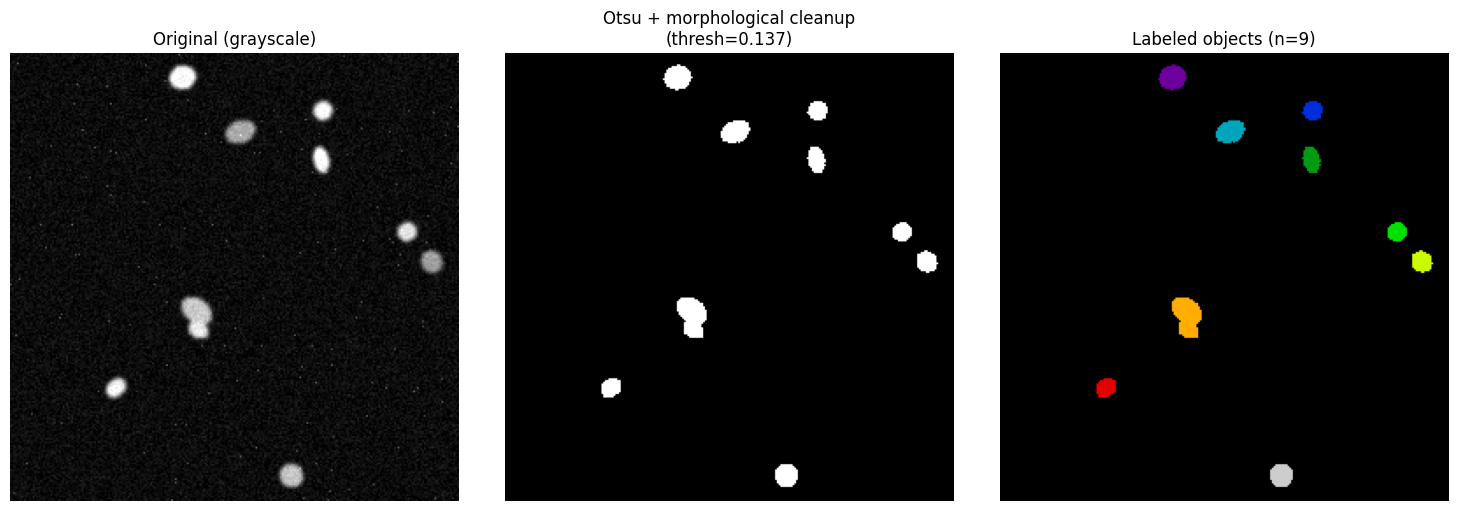

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample['gray_array'], cmap='gray')
axes[0].set_title('Original (grayscale)')
axes[0].axis('off')

axes[1].imshow(result['binary_mask'], cmap='gray')
axes[1].set_title(f"Otsu + morphological cleanup\n(thresh={result['threshold']:.3f})")
axes[1].axis('off')

axes[2].imshow(result['labeled_mask'], cmap='nipy_spectral')
axes[2].set_title(f"Labeled objects (n={result['n_objects']})")
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/content/task2_segmentation_demo.png', dpi=150)
plt.show()

### Turn features into a plain-language numeric summary → send text-only to LLM

In [ ]:
def build_numeric_summary(features_result, image_id):
    """Convert regionprops output into a plain-language text summary (no image)."""
    df = features_result['props_df']
    n = features_result['n_objects']

    if n == 0:
        return f"Image {image_id}: no objects detected after segmentation."

    summary = f"""Image ID: {image_id}
Segmentation method: Otsu thresholding + morphological cleanup + connected component labeling
Number of detected objects: {n}
Object area (pixels): mean={df['area'].mean():.1f}, std={df['area'].std():.1f}, min={df['area'].min():.0f}, max={df['area'].max():.0f}
Eccentricity (0=circle, 1=line): mean={df['eccentricity'].mean():.3f}, std={df['eccentricity'].std():.3f}
Solidity (compactness, 1=fully convex): mean={df['solidity'].mean():.3f}, std={df['solidity'].std():.3f}
Mean intensity within objects: {df['mean_intensity'].mean():.3f}
Extent (area / bounding box area): mean={df['extent'].mean():.3f}
"""
    return summary.strip()

numeric_summary = build_numeric_summary(result, sample_id)
print(numeric_summary)

Image ID: train_000
Segmentation method: Otsu thresholding + morphological cleanup + connected component labeling
Number of detected objects: 9
Object area (pixels): mean=146.0, std=60.7, min=98, max=288
Eccentricity (0=circle, 1=line): mean=0.493, std=0.235
Solidity (compactness, 1=fully convex): mean=0.940, std=0.030
Mean intensity within objects: 0.260
Extent (area / bounding box area): mean=0.770


### Text-only LLM interpretation (no image passed)

In [ ]:
import json

interpretation_prompt = f"""You are analyzing quantitative output from a classical image-segmentation pipeline (Otsu thresholding + connected component analysis) applied to a microscopy image. You are NOT shown the image itself — only the numeric summary below. Do not speculate about anything not derivable from these numbers.

{numeric_summary}

Based only on this numeric data, respond ONLY with valid JSON in exactly this format:
{{
  "n_objects": <integer>,
  "density_class": "<your estimate: sparse, normal, dense, or clustered, based on object count and area>",
  "shape_regularity": "<assessment based on eccentricity and solidity values, e.g. 'mostly round and regular' or 'irregular/elongated'>",
  "quality_flag": "<any concern about the segmentation quality inferable from these stats, or 'no concerns'>"
}}
Do not include any text outside the JSON object."""

text_llm_response = ollama.chat(
    model='llava',
    messages=[{'role': 'user', 'content': interpretation_prompt}]
)

text_llm_output = text_llm_response['message']['content']
print("=== TASK 2: TEXT-ONLY LLM INTERPRETATION ===")
print(text_llm_output)

# Save everything for the report / Task 2 vs Task 1 comparison
with open('/content/task2_output.json', 'w') as f:
    json.dump({
        'image_id': sample_id,
        'ground_truth_n_objects': int(gt_row['n_objects']),
        'detected_n_objects': result['n_objects'],
        'otsu_threshold': float(result['threshold']),
        'numeric_summary': numeric_summary,
        'llm_prompt': interpretation_prompt,
        'llm_output': text_llm_output
    }, f, indent=2)


=== TASK 2: TEXT-ONLY LLM INTERPRETATION ===
 {
  "n\_objects": 9,
  "density\_class": "normal",
  "shape\_regularity": "mostly round and regular",
  "quality\_flag": "no concerns"
} 


## U-Net pipeline

### Dataset class

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from PIL import Image
import numpy as np
import os

class NucleiDataset(Dataset):
    def __init__(self, root_dir, split, target_size=(256, 256)):
        self.img_dir = f'{root_dir}/{split}/images'
        self.mask_dir = f'{root_dir}/{split}/masks'
        self.ids = sorted([f.replace('.png', '') for f in os.listdir(self.img_dir)])
        self.target_size = target_size

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img = Image.open(f'{self.img_dir}/{img_id}.png').convert('L')  # grayscale input
        mask = Image.open(f'{self.mask_dir}/{img_id}.png').convert('L')

        if img.size != self.target_size:
            img = img.resize(self.target_size, Image.BILINEAR)
            mask = mask.resize(self.target_size, Image.NEAREST)

        img_t = TF.to_tensor(img)  # [1, H, W], float in [0,1]
        mask_arr = (np.array(mask) > 127).astype(np.float32)  # binarize
        mask_t = torch.from_numpy(mask_arr).unsqueeze(0)  # [1, H, W]

        return img_t, mask_t, img_id

train_ds = NucleiDataset(EXTRACT_DIR, 'train')
val_ds = NucleiDataset(EXTRACT_DIR, 'val')
test_ds = NucleiDataset(EXTRACT_DIR, 'test')

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
img, mask, img_id = train_ds[0]
print(f"Image shape: {img.shape}, Mask shape: {mask.shape}, unique mask values: {mask.unique()}")

Train: 80, Val: 20, Test: 12
Image shape: torch.Size([1, 256, 256]), Mask shape: torch.Size([1, 256, 256]), unique mask values: tensor([0., 1.])


### U-Net architecture

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_ch=32):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConv(in_channels, base_ch)
        self.enc2 = DoubleConv(base_ch, base_ch*2)
        self.enc3 = DoubleConv(base_ch*2, base_ch*4)
        self.enc4 = DoubleConv(base_ch*4, base_ch*8)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(base_ch*8, base_ch*16)

        # Decoder
        self.up4 = nn.ConvTranspose2d(base_ch*16, base_ch*8, 2, stride=2)
        self.dec4 = DoubleConv(base_ch*16, base_ch*8)
        self.up3 = nn.ConvTranspose2d(base_ch*8, base_ch*4, 2, stride=2)
        self.dec3 = DoubleConv(base_ch*8, base_ch*4)
        self.up2 = nn.ConvTranspose2d(base_ch*4, base_ch*2, 2, stride=2)
        self.dec2 = DoubleConv(base_ch*4, base_ch*2)
        self.up1 = nn.ConvTranspose2d(base_ch*2, base_ch, 2, stride=2)
        self.dec1 = DoubleConv(base_ch*2, base_ch)

        self.out_conv = nn.Conv2d(base_ch, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))
        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out_conv(d1)  # logits, [B, 1, H, W]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model = UNet(in_channels=1, out_channels=1, base_ch=32).to(device)
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Total params: 7,765,409


### Loss functions, Dice/IoU metrics

In [ ]:
def dice_coefficient(pred_logits, target, eps=1e-6):
    pred = torch.sigmoid(pred_logits) > 0.5
    pred = pred.float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean().item()

def iou_score(pred_logits, target, eps=1e-6):
    pred = torch.sigmoid(pred_logits) > 0.5
    pred = pred.float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

class DiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps
    def forward(self, logits, target):
        pred = torch.sigmoid(logits)
        intersection = (pred * target).sum(dim=(1,2,3))
        union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
        dice = (2 * intersection + self.eps) / (union + self.eps)
        return 1 - dice.mean()

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
    def forward(self, logits, target):
        return self.bce(logits, target) + self.dice(logits, target)

criterion = BCEDiceLoss()

### Training loop

In [ ]:
import time

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

NUM_EPOCHS = 40
history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}

best_val_dice = 0.0
best_model_path = '/content/drive/MyDrive/best_unet_nuclei.pth'

for epoch in range(NUM_EPOCHS):
    model.train()
    train_losses = []
    for imgs, masks, _ in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses, val_dices, val_ious = [], [], []
    with torch.no_grad():
        for imgs, masks, _ in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss = criterion(logits, masks)
            val_losses.append(loss.item())
            val_dices.append(dice_coefficient(logits, masks))
            val_ious.append(iou_score(logits, masks))

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)
    val_dice = np.mean(val_dices)
    val_iou = np.mean(val_ious)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_dice={val_dice:.4f} | val_iou={val_iou:.4f}")

print(f"\nBest val Dice: {best_val_dice:.4f}, saved to {best_model_path}")

Epoch 1/40 | train_loss=1.2398 | val_loss=1.4950 | val_dice=0.0000 | val_iou=0.0000
Epoch 2/40 | train_loss=1.0590 | val_loss=1.2062 | val_dice=0.8246 | val_iou=0.7033
Epoch 3/40 | train_loss=0.9804 | val_loss=1.0179 | val_dice=0.9003 | val_iou=0.8189
Epoch 4/40 | train_loss=0.9200 | val_loss=0.9397 | val_dice=0.8859 | val_iou=0.7955
Epoch 5/40 | train_loss=0.8618 | val_loss=0.9152 | val_dice=0.8631 | val_iou=0.7599
Epoch 6/40 | train_loss=0.8082 | val_loss=0.8342 | val_dice=0.8977 | val_iou=0.8148
Epoch 7/40 | train_loss=0.7542 | val_loss=0.7456 | val_dice=0.9402 | val_iou=0.8874
Epoch 8/40 | train_loss=0.7036 | val_loss=0.7272 | val_dice=0.9756 | val_iou=0.9524
Epoch 9/40 | train_loss=0.6529 | val_loss=0.6591 | val_dice=0.9767 | val_iou=0.9545
Epoch 10/40 | train_loss=0.6057 | val_loss=0.6105 | val_dice=0.9929 | val_iou=0.9858
Epoch 11/40 | train_loss=0.5563 | val_loss=0.5761 | val_dice=0.9941 | val_iou=0.9883
Epoch 12/40 | train_loss=0.5122 | val_loss=0.4996 | val_dice=0.9921 | val_

### Plot loss/Dice/IoU curves

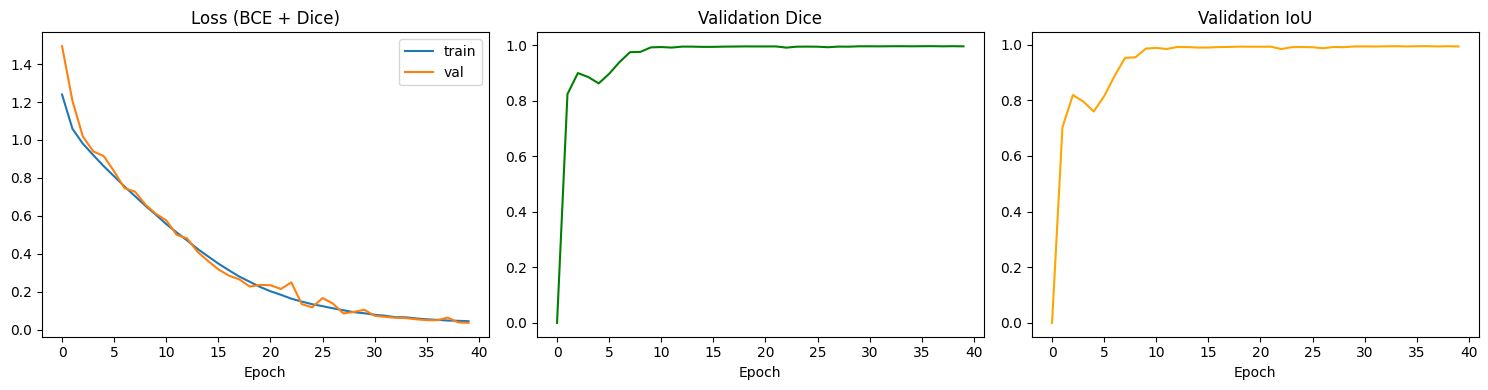

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss (BCE + Dice)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['val_dice'], color='green')
axes[1].set_title('Validation Dice')
axes[1].set_xlabel('Epoch')

axes[2].plot(history['val_iou'], color='orange')
axes[2].set_title('Validation IoU')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('/content/task3_training_curves.png', dpi=150)
plt.show()

### Prediction panels on ≥3 validation images

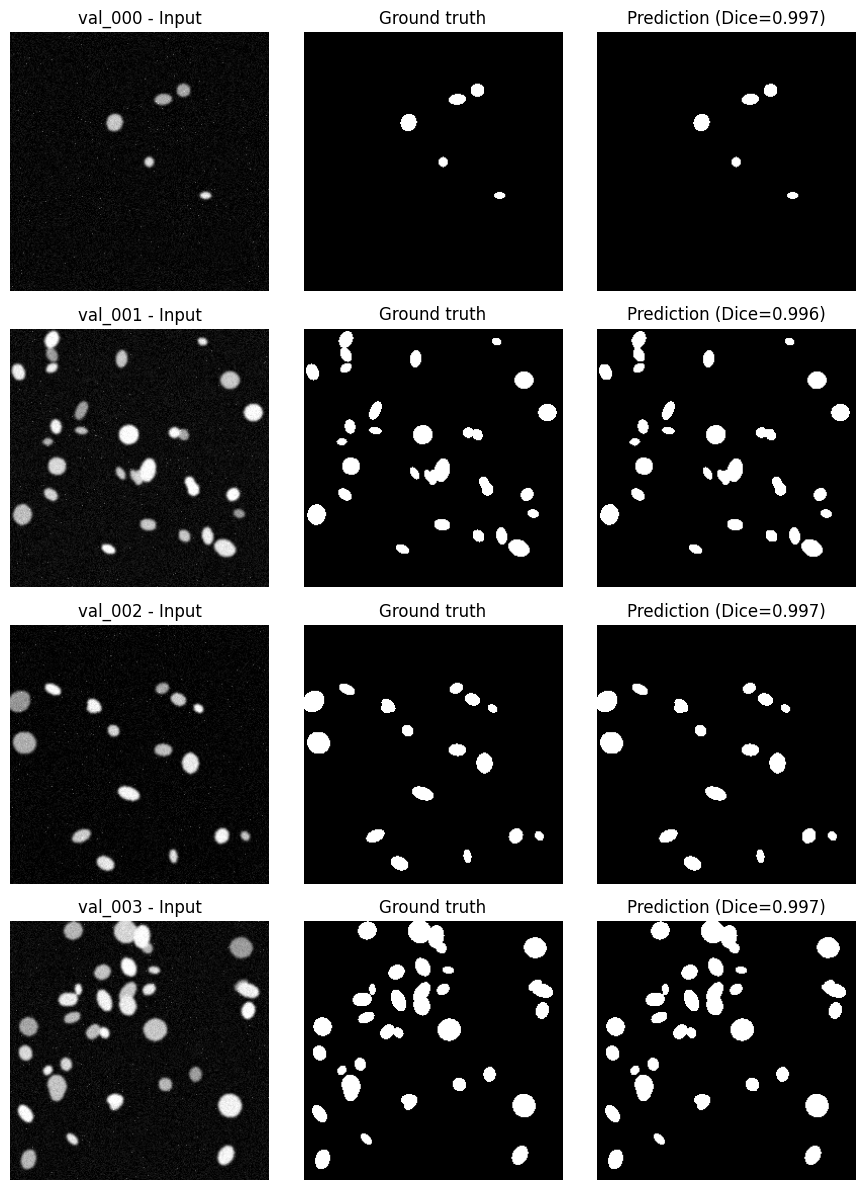

In [ ]:
model.load_state_dict(torch.load(best_model_path))
model.eval()

n_show = 4
fig, axes = plt.subplots(n_show, 3, figsize=(9, 3*n_show))

with torch.no_grad():
    for i in range(n_show):
        img, mask, img_id = val_ds[i]
        img_batch = img.unsqueeze(0).to(device)
        logits = model(img_batch)
        pred = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze().numpy()

        axes[i,0].imshow(img.squeeze(), cmap='gray')
        axes[i,0].set_title(f'{img_id} - Input')
        axes[i,0].axis('off')

        axes[i,1].imshow(mask.squeeze(), cmap='gray')
        axes[i,1].set_title('Ground truth')
        axes[i,1].axis('off')

        axes[i,2].imshow(pred, cmap='gray')
        dice_val = dice_coefficient(logits, mask.unsqueeze(0).to(device))
        axes[i,2].set_title(f'Prediction (Dice={dice_val:.3f})')
        axes[i,2].axis('off')

plt.tight_layout()
plt.savefig('/content/task3_prediction_panels.png', dpi=150)
plt.show()

## Hybrid pipeline on the test set

In [ ]:
def run_hybrid_pipeline(model, dataset, device):
    model.eval()
    records = []

    with torch.no_grad():
        for img_t, mask_t, img_id in dataset:
            img_batch = img_t.unsqueeze(0).to(device)
            logits = model(img_batch)
            pred_mask = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze().numpy()

            # regionprops on U-Net's predicted mask
            labeled = measure.label(pred_mask.astype(bool))
            props = measure.regionprops_table(
                labeled, intensity_image=img_t.squeeze().numpy(),
                properties=['label', 'area', 'eccentricity', 'solidity', 'mean_intensity']
            )
            props_df = pd.DataFrame(props)
            n_objects = int(labeled.max())

            if n_objects == 0:
                mean_area = 0.0
            else:
                mean_area = float(props_df['area'].mean())

            # density_class heuristic from object count (same bins as metadata.csv regimes)
            if n_objects < 15:
                density_class = 'sparse'
            elif n_objects < 40:
                density_class = 'normal'
            else:
                density_class = 'dense'  # clustered vs dense not distinguishable from count alone

            quality_flag = 'no concerns' if n_objects > 0 else 'no objects detected - check input'

            # text-only LLM call -> JSON + narrative
            numeric_summary = f"""Image ID: {img_id}
Segmentation method: U-Net (trained), thresholded at 0.5
Number of detected objects: {n_objects}
Mean object area (pixels): {mean_area:.1f}
Mean eccentricity: {props_df['eccentricity'].mean():.3f} (if available)
Mean solidity: {props_df['solidity'].mean():.3f} (if available)"""

            prompt = f"""You are summarizing quantitative output from a trained U-Net segmentation model applied to a microscopy image, plus shape statistics from the resulting mask. You are NOT shown the image itself.

{numeric_summary}

Respond ONLY with valid JSON in exactly this format:
{{
  "image_id": "{img_id}",
  "n_objects": {n_objects},
  "mean_area": {mean_area:.1f},
  "density_class": "<sparse, normal, or dense, based on object count>",
  "quality_flag": "<any concern inferable from these stats, or 'no concerns'>"
}}
Then, on a new line after the JSON, write one short narrative sentence (max 25 words) summarizing this image in plain language for a lab report."""

            resp = ollama.chat(model='llava', messages=[{'role': 'user', 'content': prompt}])
            llm_output = resp['message']['content']

            records.append({
                'image_id': img_id,
                'n_objects_detected': n_objects,
                'mean_area': mean_area,
                'density_class_heuristic': density_class,
                'llm_raw_output': llm_output
            })
            print(f"Processed {img_id}: n={n_objects}, mean_area={mean_area:.1f}")

    return pd.DataFrame(records)

test_results_df = run_hybrid_pipeline(model, test_ds, device)
print(test_results_df)

Processed test_000: n=8, mean_area=190.9
Processed test_001: n=14, mean_area=200.6
Processed test_002: n=26, mean_area=219.6
Processed test_003: n=19, mean_area=203.4
Processed test_004: n=43, mean_area=329.1
Processed test_005: n=17, mean_area=382.9
Processed test_006: n=8, mean_area=197.5
Processed test_007: n=23, mean_area=205.9
Processed test_008: n=23, mean_area=240.0
Processed test_009: n=21, mean_area=178.5
Processed test_010: n=38, mean_area=344.1
Processed test_011: n=20, mean_area=183.7
    image_id  n_objects_detected   mean_area density_class_heuristic  \
0   test_000                   8  190.875000                  sparse   
1   test_001                  14  200.642857                  sparse   
2   test_002                  26  219.615385                  normal   
3   test_003                  19  203.421053                  normal   
4   test_004                  43  329.139535                   dense   
5   test_005                  17  382.941176                  norm

### Save aggregated CSV + compare against ground truth

In [ ]:
# Merge with true metadata for a sanity check
test_meta = metadata[metadata['split'] == 'test'][['image_id', 'n_objects', 'density']]
comparison_df = test_results_df.merge(test_meta, on='image_id', suffixes=('_pred', '_true'))
comparison_df['count_error'] = comparison_df['n_objects_detected'] - comparison_df['n_objects']

print(comparison_df[['image_id', 'n_objects_detected', 'n_objects', 'count_error', 'density_class_heuristic', 'density']])
print(f"\nMean absolute count error: {comparison_df['count_error'].abs().mean():.2f}")

# Save final deliverable CSV
test_results_df.to_csv('/content/task4_hybrid_results.csv', index=False)
comparison_df.to_csv('/content/task4_hybrid_results_with_ground_truth.csv', index=False)


    image_id  n_objects_detected  n_objects  count_error  \
0   test_000                   8          8            0   
1   test_001                  14         19           -5   
2   test_002                  26         31           -5   
3   test_003                  19         21           -2   
4   test_004                  43         75          -32   
5   test_005                  17         49          -32   
6   test_006                   8          8            0   
7   test_007                  23         30           -7   
8   test_008                  23         28           -5   
9   test_009                  21         24           -3   
10  test_010                  38         78          -40   
11  test_011                  20         30          -10   

   density_class_heuristic    density  
0                   sparse     sparse  
1                   sparse     normal  
2                   normal     normal  
3                   normal     normal  
4                  

### Robustness-under-corruption trace

['test_000_blur.png', 'test_000_lowcontrast.png', 'test_004_blur.png', 'test_004_lowcontrast.png']


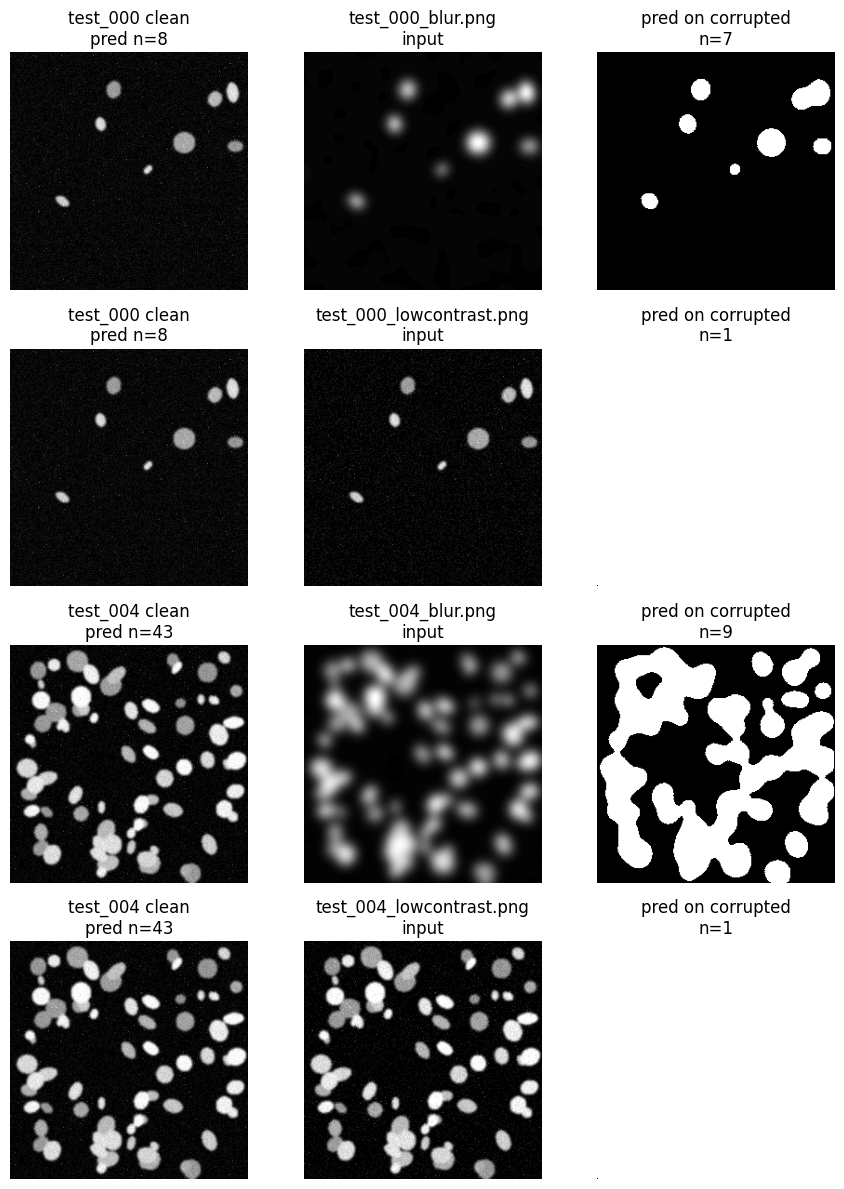

  base_image_id corruption_type  ground_truth_n_objects  \
0      test_000            blur                       8   
1      test_000     lowcontrast                       8   
2      test_004            blur                      75   
3      test_004     lowcontrast                      75   

   clean_prediction_n_objects  corrupted_prediction_n_objects  degradation  
0                           8                               7            1  
1                           8                               1            7  
2                          43                               9           34  
3                          43                               1           42  


In [ ]:
import re

corrupted_dir = f'{EXTRACT_DIR}/test_corrupted/images'
corrupted_files = sorted(os.listdir(corrupted_dir))
print(corrupted_files)

def predict_and_count(model, img_path, device, target_size=(256,256)):
    img = Image.open(img_path).convert('L')
    if img.size != target_size:
        img = img.resize(target_size, Image.BILINEAR)
    img_t = TF.to_tensor(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(img_t)
        pred_mask = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze().numpy()

    labeled = measure.label(pred_mask.astype(bool))
    n_objects = int(labeled.max())
    return pred_mask, n_objects

robustness_records = []
fig, axes = plt.subplots(len(corrupted_files), 3, figsize=(9, 3*len(corrupted_files)))

for i, fname in enumerate(corrupted_files):
    match = re.match(r'(test_\d+)_(\w+)\.png', fname)
    base_id, corruption_type = match.group(1), match.group(2)

    # Original (clean) prediction for comparison
    orig_path = f'{EXTRACT_DIR}/test/images/{base_id}.png'
    orig_mask, orig_n = predict_and_count(model, orig_path, device)

    # Corrupted prediction
    corrupt_path = f'{corrupted_dir}/{fname}'
    corrupt_mask, corrupt_n = predict_and_count(model, corrupt_path, device)

    gt_n = int(metadata[metadata['image_id'] == base_id]['n_objects'].values[0])

    robustness_records.append({
        'base_image_id': base_id,
        'corruption_type': corruption_type,
        'ground_truth_n_objects': gt_n,
        'clean_prediction_n_objects': orig_n,
        'corrupted_prediction_n_objects': corrupt_n,
        'degradation': orig_n - corrupt_n
    })

    axes[i,0].imshow(Image.open(orig_path).convert('L'), cmap='gray')
    axes[i,0].set_title(f'{base_id} clean\npred n={orig_n}')
    axes[i,0].axis('off')

    axes[i,1].imshow(Image.open(corrupt_path).convert('L'), cmap='gray')
    axes[i,1].set_title(f'{fname}\ninput')
    axes[i,1].axis('off')

    axes[i,2].imshow(corrupt_mask, cmap='gray')
    axes[i,2].set_title(f'pred on corrupted\nn={corrupt_n}')
    axes[i,2].axis('off')

plt.tight_layout()
plt.savefig('/content/task4_robustness_trace.png', dpi=150)
plt.show()

robustness_df = pd.DataFrame(robustness_records)
print(robustness_df)
robustness_df.to_csv('/content/task4_robustness_results.csv', index=False)